# Multivariate time series forecasting using  LSTM

Predicts a future value (e.g., temperature) using multiple (3) input features (e.g., temperature, humidity, pressure, etc.).

In [63]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. Create synthetic multivariate data
# -------------------------------
np.random.seed(42)
timesteps = 300
t = np.arange(timesteps)

# Example features: temperature, humidity, pressure
temperature = 20 + 0.05 * t + np.random.normal(0, 0.5, timesteps)
humidity = 60 + np.sin(0.1 * t) * 10 + np.random.normal(0, 1, timesteps)
pressure = 1013 + np.cos(0.1 * t) * 5 + np.random.normal(0, 0.5, timesteps)

data = pd.DataFrame({
    'temperature': temperature,
    'humidity': humidity,
    'pressure': pressure
})

print("Data shape:", data.shape)
print(data.head(20))

Data shape: (300, 3)
    temperature   humidity     pressure
0     20.248357  59.171005  1018.378494
1     19.980868  60.438153  1017.513938
2     20.423844  62.733987  1018.335136
3     20.911515  63.565572  1018.454501
4     20.082923  63.873282  1017.812022
5     20.132932  64.911583  1018.326311
6     21.089606  66.924090  1016.739783
7     20.733717  65.850605  1016.201884
8     20.165263  67.720658  1015.594173
9     20.721280  67.631076  1016.856072
10    20.268291  68.197029  1016.028694
11    20.317135  70.010850  1015.240188
12    20.720981  70.145807  1014.951773
13    19.693360  70.449091  1013.774750
14    19.837541  71.159976  1015.072712
15    20.468856  69.995954  1013.418297
16    20.293584  70.677689  1012.908700
17    21.007124  69.606381  1012.718661
18    20.445988  70.062643  1012.104494
19    20.243848  69.332858  1011.495494


In [64]:
# -------------------------------
# 2. Prepare data for supervised learning
# -------------------------------
def create_dataset(dataset, look_back=3):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        y.append(dataset[i + look_back, 0])  # Predict temperature
    return np.array(X), np.array(y)

# Normalize all features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
print("Scaled data shape:", scaled_data.shape)
print(scaled_data[:20])

Scaled data shape: (300, 3)
[[0.03554696 0.46523833 0.96642258]
 [0.01841457 0.51734616 0.89165302]
 [0.04678672 0.61175573 0.96267281]
 [0.07802149 0.64595229 0.97299592]
 [0.02495111 0.65860596 0.9174323 ]
 [0.02815408 0.70130311 0.96190958]
 [0.08942805 0.78406167 0.82470167]
 [0.06663375 0.73991772 0.77818238]
 [0.03022486 0.81681827 0.72562568]
 [0.06583715 0.81313447 0.83475867]
 [0.03682371 0.83640763 0.76320443]
 [0.03995212 0.91099584 0.69501192]
 [0.06581801 0.91654555 0.67006886]
 [0.         0.92901725 0.56827613]
 [0.00923465 0.95825034 0.68052801]
 [0.04966969 0.91038326 0.53744894]
 [0.03844372 0.93841766 0.49337739]
 [0.08414512 0.89436321 0.47694222]
 [0.048205   0.91312565 0.42382713]
 [0.03525817 0.88311534 0.37115888]]


In [65]:
look_back = 7
X, y = create_dataset(scaled_data, look_back)

print("--- X shape:", X.shape)  # (samples, timesteps, features)
print(X[:5])
print("--- y shape:", y.shape)
print(y[:10])

--- X shape: (293, 7, 3)
[[[0.03554696 0.46523833 0.96642258]
  [0.01841457 0.51734616 0.89165302]
  [0.04678672 0.61175573 0.96267281]
  [0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]]

 [[0.01841457 0.51734616 0.89165302]
  [0.04678672 0.61175573 0.96267281]
  [0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]
  [0.06663375 0.73991772 0.77818238]]

 [[0.04678672 0.61175573 0.96267281]
  [0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]
  [0.06663375 0.73991772 0.77818238]
  [0.03022486 0.81681827 0.72562568]]

 [[0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]
  [0.06663375 0.73991772 0.77818238]
  [0.03

In [66]:
# Split into train and test using sklearn.model_selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("X_train shape:", X_train.shape)
print(f"-----------------------------------X_train:\n{X_train[:10]}")
print("y_train shape:", y_train.shape)
print(f"-----------------------------------y_train:\n{y_train[:10]}")
print("X_test shape:", X_test.shape)
print(f"-----------------------------------X_test:\n{X_test[:10]}")
print("y_test shape:", y_test.shape)
print(f"-----------------------------------y_test:\n{y_test[:10]}")

X_train shape: (234, 7, 3)
-----------------------------------X_train:
[[[0.03554696 0.46523833 0.96642258]
  [0.01841457 0.51734616 0.89165302]
  [0.04678672 0.61175573 0.96267281]
  [0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]]

 [[0.01841457 0.51734616 0.89165302]
  [0.04678672 0.61175573 0.96267281]
  [0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]
  [0.06663375 0.73991772 0.77818238]]

 [[0.04678672 0.61175573 0.96267281]
  [0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167]
  [0.06663375 0.73991772 0.77818238]
  [0.03022486 0.81681827 0.72562568]]

 [[0.07802149 0.64595229 0.97299592]
  [0.02495111 0.65860596 0.9174323 ]
  [0.02815408 0.70130311 0.96190958]
  [0.08942805 0.78406167 0.82470167

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1627 - val_loss: 0.0992
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0419 - val_loss: 0.0633
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133 - val_loss: 0.0047
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - val_loss: 0.0074
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 0.0027
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - val_loss: 0.0043
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_l

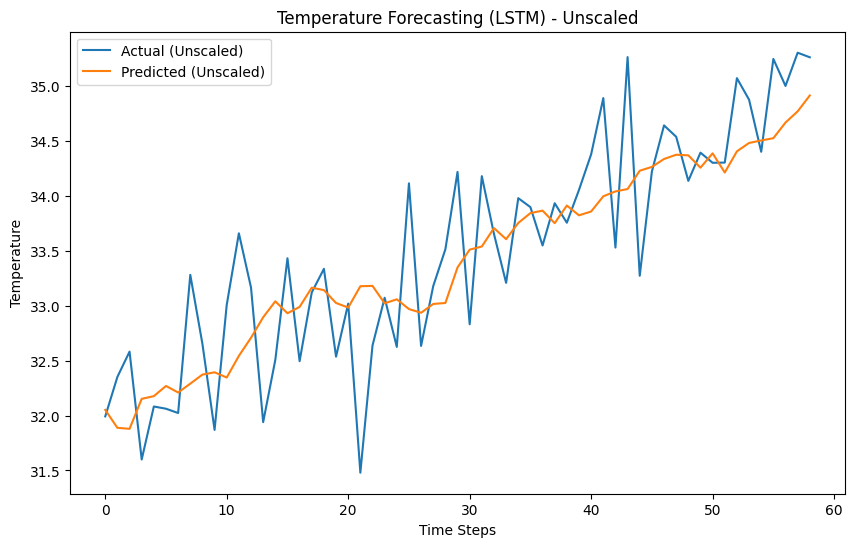

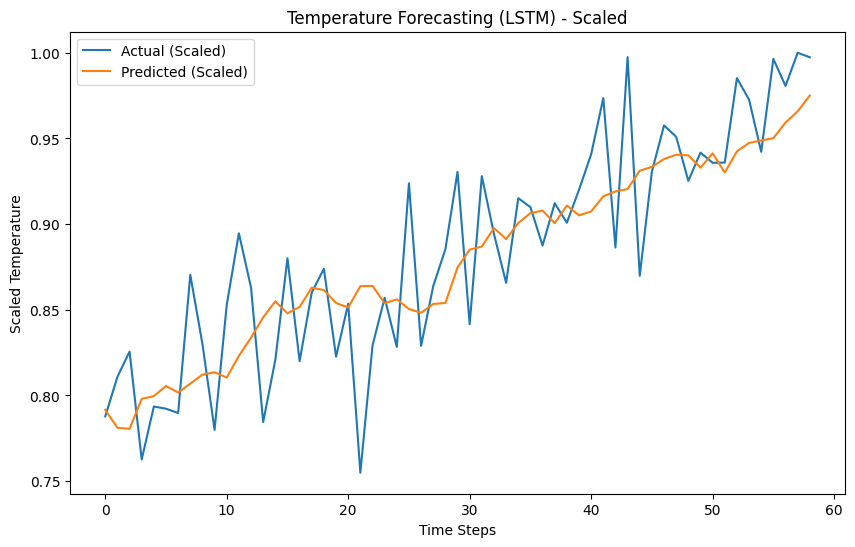

Root Mean Squared Error (RMSE) on unscaled test data: 0.5670
Root Mean Squared Error (RMSE) on scaled test data: 0.0363


In [62]:

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    LSTM(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

predicted = model.predict(X_test)

dummy_predicted = np.zeros((len(predicted), scaled_data.shape[1]))
dummy_predicted[:, 0] = predicted[:, 0]
predicted_unscaled = scaler.inverse_transform(dummy_predicted)[:, 0]

dummy_y_test = np.zeros((len(y_test), scaled_data.shape[1]))
dummy_y_test[:, 0] = y_test
y_test_unscaled = scaler.inverse_transform(dummy_y_test)[:, 0]


plt.figure(figsize=(10, 6))
plt.plot(y_test_unscaled, label='Actual (Unscaled)')
plt.plot(predicted_unscaled, label='Predicted (Unscaled)')
plt.title('Temperature Forecasting (LSTM) - Unscaled')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Scaled)')
plt.plot(predicted, label='Predicted (Scaled)')
plt.title('Temperature Forecasting (LSTM) - Scaled')
plt.xlabel('Time Steps')
plt.ylabel('Scaled Temperature')
plt.legend()
plt.show()

rmse_unscaled = np.sqrt(mean_squared_error(y_test_unscaled, predicted_unscaled))
print(f"Root Mean Squared Error (RMSE) on unscaled test data: {rmse_unscaled:.4f}")

rmse_scaled = np.sqrt(mean_squared_error(y_test, predicted))
print(f"Root Mean Squared Error (RMSE) on scaled test data: {rmse_scaled:.4f}")